# K05_02 – Logistische Regression: Lernerfolg klassifizieren

## Lernziele
- einen kleinen Klassifikationsdatensatz verstehen
- logistische Regression trainieren
- Wahrscheinlichkeiten für neue Fälle interpretieren
- Konfusionsmatrix, Precision, Recall und F1 anwenden

## 1. Bibliotheken importieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

## 2. Beispieldaten erzeugen

Wir verwenden einen kleinen fiktiven Datensatz mit zwei Merkmalen:

- `lernzeit`: Stunden pro Woche
- `anwesenheit`: Anwesenheitsquote in Prozent

Zielvariable:
- `1` = bestanden
- `0` = nicht bestanden

In [2]:
np.random.seed(42)

n_samples = 120

lernzeit = np.random.uniform(0, 20, n_samples)
anwesenheit = np.random.uniform(40, 100, n_samples)

# künstliche, aber plausible Regel mit Zufallseinfluss
score = 0.25 * lernzeit + 0.06 * anwesenheit - 5.5 + np.random.normal(0, 0.7, n_samples)
y = (score > 0).astype(int)

X = np.column_stack([lernzeit, anwesenheit])

print("Shape von X:", X.shape)
print("Shape von y:", y.shape)
print("Anzahl Klasse 0:", np.sum(y == 0))
print("Anzahl Klasse 1:", np.sum(y == 1))

Shape von X: (120, 2)
Shape von y: (120,)
Anzahl Klasse 0: 36
Anzahl Klasse 1: 84


## 3. Daten visualisieren

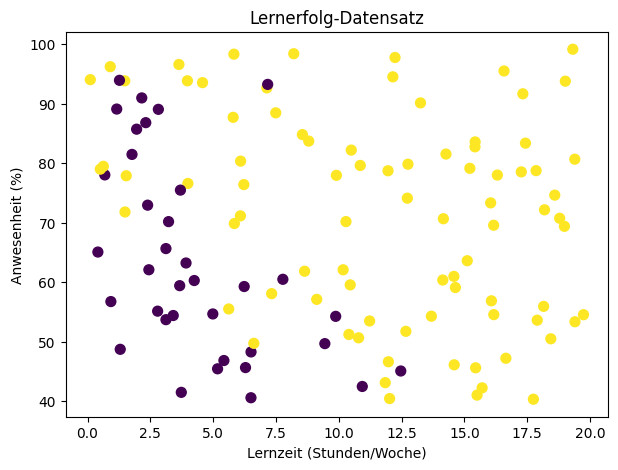

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.xlabel("Lernzeit (Stunden/Woche)")
plt.ylabel("Anwesenheit (%)")
plt.title("Lernerfolg-Datensatz")
plt.show()

## 4. Trainings- und Testdaten erzeugen

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Trainingsdaten:", X_train.shape, y_train.shape)
print("Testdaten     :", X_test.shape, y_test.shape)

Trainingsdaten: (84, 2) (84,)
Testdaten     : (36, 2) (36,)


## 5. Modell trainieren

In [5]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

## 6. Vorhersagen und Metriken

In [6]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(acc, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-Score :", round(f1, 3))
print("\nKonfusionsmatrix:\n", cm)

Accuracy : 0.806
Precision: 0.8
Recall   : 0.96
F1-Score : 0.873

Konfusionsmatrix:
 [[ 5  6]
 [ 1 24]]


## 7. Wahrscheinlichkeiten für neue Fälle

In [7]:
neue_faelle = np.array([
    [4, 55],
    [10, 80],
    [15, 92]
])

proba = clf.predict_proba(neue_faelle)[:, 1]
pred = clf.predict(neue_faelle)

for fall, p, c in zip(neue_faelle, proba, pred):
    print(f"Lernzeit={fall[0]:>2}, Anwesenheit={fall[1]:>2} -> P(bestanden)={p:.3f}, Vorhersage={c}")

Lernzeit= 4, Anwesenheit=55 -> P(bestanden)=0.127, Vorhersage=0
Lernzeit=10, Anwesenheit=80 -> P(bestanden)=0.989, Vorhersage=1
Lernzeit=15, Anwesenheit=92 -> P(bestanden)=1.000, Vorhersage=1


## 8. Kleine Übung

**Aufgabe 1:**  
Interpretieren Sie die Konfusionsmatrix in Worten.
Es gibt 5 TP, 6 FP, 1 FN und 24 TN. Die große Menge an TN deutet darauf hin, dass ein Großteil der Schüler aus den Testdaten die Prüfung nicht bestehen,

**Aufgabe 2:**  
Welcher neue Fall erscheint Ihnen besonders sicher? Welcher eher grenzwertig?

**Aufgabe 3:**  
Ändern Sie einen der drei neuen Fälle leicht ab und beobachten Sie, wie sich die Wahrscheinlichkeit verändert.

### Lösung Aufgabe 1: Interpretation der Konfusionsmatrix

Die Konfusionsmatrix `[[ 5  6] [ 1 24]]` bedeutet:

*   **5 True Negatives (TN):** 5 Studierende wurden korrekt als "nicht bestanden" vorhergesagt, und haben tatsächlich nicht bestanden.
*   **6 False Positives (FP):** 6 Studierende wurden fälschlicherweise als "bestanden" vorhergesagt, obwohl sie tatsächlich nicht bestanden haben (Typ-I-Fehler).
*   **1 False Negative (FN):** 1 Studierender wurde fälschlicherweise als "nicht bestanden" vorhergesagt, obwohl er tatsächlich bestanden hat (Typ-II-Fehler).
*   **24 True Positives (TP):** 24 Studierende wurden korrekt als "bestanden" vorhergesagt, und haben tatsächlich bestanden.

Die Aussage, dass eine große Menge an TN darauf hindeutet, dass ein Großteil der Schüler die Prüfung nicht besteht, ist nicht ganz korrekt. Es bedeutet, dass das Modell 5 Fälle, die nicht bestanden haben, korrekt identifiziert hat. Die 24 TP zeigen, dass ein Großteil der Studierenden bestanden hat und das Modell diese korrekt vorhergesagt hat. Die 6 FP sind hier ein Bereich, in dem das Modell zu optimistisch war.

### Lösung Aufgabe 2: Sicherheit der Vorhersagen

Basierend auf den Wahrscheinlichkeiten `P(bestanden)`:

*   **Besonders sicher (bestanden):** Der Fall mit `Lernzeit=15, Anwesenheit=92` und `P(bestanden)=1.000` erscheint sehr sicher, dass er bestanden hat.
*   **Besonders sicher (nicht bestanden):** Der Fall mit `Lernzeit= 4, Anwesenheit=55` und `P(bestanden)=0.127` erscheint sehr sicher, dass er nicht bestanden hat, da die Wahrscheinlichkeit zu bestehen sehr gering ist.
*   **Eher grenzwertig:** Unter den gegebenen Beispielen ist `Lernzeit= 4, Anwesenheit=55` (`P(bestanden)=0.127`) der Fall, der am nächsten an der Entscheidungsgrenze (typischerweise 0.5) liegt, auch wenn er noch relativ deutlich unter der Grenze liegt. Ein Fall mit einer Wahrscheinlichkeit nahe 0.5 wäre am grenzwertigsten.

In [8]:
# TODO: Definieren Sie einen eigenen neuen Fall und berechnen Sie dessen Wahrscheinlichkeit.
# eigener_fall = np.array([[..., ...]])
# ...

In [9]:
# TODO: Definieren Sie einen eigenen neuen Fall und berechnen Sie dessen Wahrscheinlichkeit.
# eigener_fall = np.array([[..., ...]])
# ...

# Modifizieren eines der drei neuen Fälle und Beobachten der Wahrscheinlichkeitsänderung.
# Beispiel: Erhöhen wir die Lernzeit für den ersten Fall ([4, 55]) leicht.

eigener_fall_modifiziert = np.array([[6, 55]]) # Lernzeit von 4 auf 6 erhöht, Anwesenheit bleibt gleich

proba_modifiziert = clf.predict_proba(eigener_fall_modifiziert)[:, 1]
pred_modifiziert = clf.predict(eigener_fall_modifiziert)

for fall, p, c in zip(eigener_fall_modifiziert, proba_modifiziert, pred_modifiziert):
    print(f"Modifizierter Fall: Lernzeit={fall[0]:>2}, Anwesenheit={fall[1]:>2} -> P(bestanden)={p:.3f}, Vorhersage={c}")

print("\nZum Vergleich der ursprüngliche Fall:")
for fall, p, c in zip(neue_faelle[0:1], proba[0:1], pred[0:1]):
    print(f"Original Fall: Lernzeit={fall[0]:>2}, Anwesenheit={fall[1]:>2} -> P(bestanden)={p:.3f}, Vorhersage={c}")

Modifizierter Fall: Lernzeit= 6, Anwesenheit=55 -> P(bestanden)=0.333, Vorhersage=0

Zum Vergleich der ursprüngliche Fall:
Original Fall: Lernzeit= 4, Anwesenheit=55 -> P(bestanden)=0.127, Vorhersage=0


## 9. Reflexion
- Worin unterscheiden sich Accuracy und F1-Score?
Accuracy berechnet das Verhältnis der korrekt klassifizierten Fälle zu allen Fällen, F1-Score ist das harmonische Mittel von Präzision und Sensitivität und stellt ein geeignetes Maß für die Gesamtqualität des Klassifikators dar.
- Wann wäre Recall wichtiger als Precision?


### Lösung Aufgabe 4: Reflexion

**Worin unterscheiden sich Accuracy und F1-Score?**
*   **Accuracy (Genauigkeit):** Misst den Anteil der korrekt klassifizierten Fälle (True Positives und True Negatives) an allen Fällen. Sie ist ein gutes Maß, wenn die Klassen im Datensatz ausgeglichen sind. Bei unbalancierten Datensätzen kann eine hohe Accuracy irreführend sein, da das Modell einfach die Mehrheitsklasse vorhersagen könnte und trotzdem eine scheinbar gute Genauigkeit erreicht.
*   **F1-Score:** Ist das harmonische Mittel aus Precision (Präzision) und Recall (Sensitivität/Erinnerungsrate). Er bietet einen besseren Einblick in die Leistung eines Modells, insbesondere bei unbalancierten Datensätzen, da er sowohl False Positives als auch False Negatives berücksichtigt. Ein hoher F1-Score zeigt an, dass das Modell sowohl präzise ist (wenige False Positives) als auch viele relevante Fälle findet (wenige False Negatives).

**Wann wäre Recall wichtiger als Precision?**
*   **Recall (Sensitivität):** Ist wichtig, wenn die Kosten für False Negatives (FN) sehr hoch sind. Ein False Negative bedeutet, dass ein positiver Fall fälschlicherweise als negativ klassifiziert wurde. Man möchte möglichst alle positiven Fälle erkennen.
    *   **Beispiel:** Bei der Diagnose einer schweren Krankheit (z.B. Krebs) ist Recall wichtiger. Es ist schlimmer, einen kranken Patienten zu übersehen (FN) als einen gesunden Patienten fälschlicherweise als krank zu diagnostizieren (FP), da ein False Negative zu fehlender Behandlung führen kann. Ein False Positive würde zwar weitere Untersuchungen nach sich ziehen, aber keine unmittelbare Lebensgefahr bedeuten.
    *   **Beispiel:** Im Bereich der Sicherheit (z.B. Erkennung von Betrug oder Terrorismus). Es ist entscheidend, alle potenziellen Bedrohungen zu erkennen, auch wenn dies zu einigen Fehlalarmen (FP) führt.

*   **Precision (Präzision):** Ist wichtig, wenn die Kosten für False Positives (FP) sehr hoch sind. Ein False Positive bedeutet, dass ein negativer Fall fälschlicherweise als positiv klassifiziert wurde. Man möchte sicherstellen, dass alle als positiv klassifizierten Fälle auch wirklich positiv sind.
    *   **Beispiel:** Bei der Spam-Erkennung in E-Mails ist Precision wichtiger. Es ist schlimmer, eine wichtige E-Mail fälschlicherweise als Spam zu markieren (FP) als eine Spam-E-Mail durchzulassen (FN). Ein False Positive führt dazu, dass der Nutzer wichtige Informationen verpasst.
    *   **Beispiel:** Bei der Empfehlung von Produkten. Es ist besser, dem Kunden nur Produkte zu empfehlen, die er mit hoher Wahrscheinlichkeit mag (hohe Precision), auch wenn man dadurch einige Produkte verpasst (geringerer Recall).